In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#Step 2: Locate the Feature-Engineered Files
feature_folder = Path("feature_engineered")

feature_files = sorted(feature_folder.glob("*.parquet"))

print("Total files:", len(feature_files))

Total files: 4697


In [4]:
#Step 3 - Removing the sample file 
feature_files = [
    f for f in feature_files
    if f.name != "sample.parquet"
]

print("Files for EDA:", len(feature_files))

Files for EDA: 4696


In [5]:
# Step 3 - Create an EDA Sample
random.seed(42)

selected_files = random.sample(feature_files, 50)

sample_list = []

for i, file in enumerate(selected_files):

    print(f"Loading {i+1}/50 : {file.name}")

    df = pd.read_parquet(file)

    sample = df.sample(
        n=10000,
        random_state=42
    )

    sample_list.append(sample)

eda_df = pd.concat(
    sample_list,
    ignore_index=True
)

print("\nEDA Dataset Shape:", eda_df.shape)

Loading 1/50 : 2019042500.parquet
Loading 2/50 : 2019012612.parquet
Loading 3/50 : 2019100915.parquet
Loading 4/50 : 2019090818.parquet
Loading 5/50 : 2019081712.parquet
Loading 6/50 : 2019052321.parquet
Loading 7/50 : 2019041521.parquet
Loading 8/50 : 2020120309.parquet
Loading 9/50 : 2019033100.parquet
Loading 10/50 : 2020030800.parquet
Loading 11/50 : 2019020212.parquet
Loading 12/50 : 2019013112.parquet
Loading 13/50 : 2019040621.parquet
Loading 14/50 : 2019081221.parquet
Loading 15/50 : 2019082703.parquet
Loading 16/50 : 2020060109.parquet
Loading 17/50 : 2019012803.parquet
Loading 18/50 : 2020121915.parquet
Loading 19/50 : 2019072312.parquet
Loading 20/50 : 2020120300.parquet
Loading 21/50 : 2020030512.parquet
Loading 22/50 : 2019081415.parquet
Loading 23/50 : 2020040421.parquet
Loading 24/50 : 2019101218.parquet
Loading 25/50 : 2019010715.parquet
Loading 26/50 : 2019061309.parquet
Loading 27/50 : 2020030818.parquet
Loading 28/50 : 2019121509.parquet
Loading 29/50 : 2019101212.pa

In [6]:
#Step 4 - Data Overview
print("Shape:", eda_df.shape)

print("\nColumns:")
print(eda_df.columns)

print("\nData Types:")
print(eda_df.dtypes)

Shape: (500000, 16)

Columns:
Index(['time', 'pressure_hpa', 'latitude', 'longitude', 'geopotential_height',
       'temperature', 'relative_humidity', 'u_wind', 'v_wind', 'wind_speed',
       'wind_direction', 'year', 'month', 'day', 'hour', 'season'],
      dtype='str')

Data Types:
time                   datetime64[ns]
pressure_hpa                  float64
latitude                      float64
longitude                     float64
geopotential_height           float32
temperature                   float32
relative_humidity             float32
u_wind                        float32
v_wind                        float32
wind_speed                    float32
wind_direction                float32
year                            int32
month                           int32
day                             int32
hour                            int32
season                            str
dtype: object


In [7]:
#Step 5 - Null Values
eda_df.isnull().sum()

time                   0
pressure_hpa           0
latitude               0
longitude              0
geopotential_height    0
temperature            0
relative_humidity      0
u_wind                 0
v_wind                 0
wind_speed             0
wind_direction         0
year                   0
month                  0
day                    0
hour                   0
season                 0
dtype: int64

In [8]:
#Step 6 - Duplicate Rows
print("Duplicate Rows:", eda_df.duplicated().sum())

Duplicate Rows: 0


In [9]:
#Step 7 - Summary Statistics
eda_df.describe()

,time,pressure_hpa,latitude,longitude,geopotential_height,temperature,relative_humidity,u_wind,v_wind,wind_speed,wind_direction,year,month,day,hour
count,500000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,2019-09-30 13:44:24.000000512,114.39900,15.392004,74.613348,16412.302734,207.590622,21.217798,5.857034,0.338340,16.083048,194.921097,2019.300000,5.940000,13.980000,10.860000
min,2019-01-07 15:00:00,50.00000,-15.000000,30.000000,11167.117188,182.512070,0.375000,-50.551552,-56.531250,0.009572,0.000000,2019.000000,1.000000,1.000000,0.000000
25%,2019-04-15 15:00:00,70.00000,0.600000,52.560000,14061.788574,199.888565,4.610928,-6.789310,-2.988208,6.754202,96.191376,2019.000000,3.000000,8.000000,3.000000
50%,2019-08-22 07:30:00,100.00000,15.480000,75.000000,16584.957031,207.875443,16.000000,3.437994,0.161776,12.505692,240.459061,2019.000000,5.000000,12.500000,12.000000
75%,2020-01-23 12:00:00,150.00000,30.240000,96.480000,18650.636719,214.667744,33.736732,16.437500,3.414062,21.580589,272.935631,2020.000000,9.000000,22.000000,15.000000
max,2020-12-19 15:00:00,200.00000,45.000000,120.000000,21256.716797,233.737167,94.971695,93.375000,55.750000,96.863129,359.997192,2020.000000,12.000000,31.000000,21.000000
std,NaN,54.55552,17.228998,25.430525,2982.507568,9.572898,18.395401,18.514317,6.877467,12.877651,93.935036,0.458258,3.743852,8.491157,6.890609


In [10]:
#Step 8 - Unique Values
print("Pressure Levels:", sorted(eda_df["pressure_hpa"].unique()))
print()

print("Years:", sorted(eda_df["year"].unique()))
print()

print("Months:", sorted(eda_df["month"].unique()))
print()

print("Hours:", sorted(eda_df["hour"].unique()))
print()

print("Seasons:", eda_df["season"].unique())

Pressure Levels: [np.float64(50.0), np.float64(70.0), np.float64(100.0), np.float64(150.0), np.float64(200.0)]

Years: [np.int32(2019), np.int32(2020)]

Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Hours: [np.int32(0), np.int32(3), np.int32(6), np.int32(9), np.int32(12), np.int32(15), np.int32(18), np.int32(21)]

Seasons: <ArrowStringArray>
['Spring', 'Winter', 'Autumn', 'Summer']
Length: 4, dtype: str


# Data Visualtization

1. Univariate Analysis

Univariate analysis studies each feature individually.
The objective is to understand:

- Distribution
- Range
- Central tendency
- Presence of outliers
- Data quality

1.1 Wind Distribution

Wind speed is the **target variable** for this project.

Studying its distribution helps answer the following questions:

- Are low wind speeds more common than high wind speeds?
- Is the distribution symmetric or skewed?
- Are there any extreme wind events?
- Does the data require transformation before modeling?

A histogram is used because it effectively visualizes the frequency distribution of continuous numerical variables.

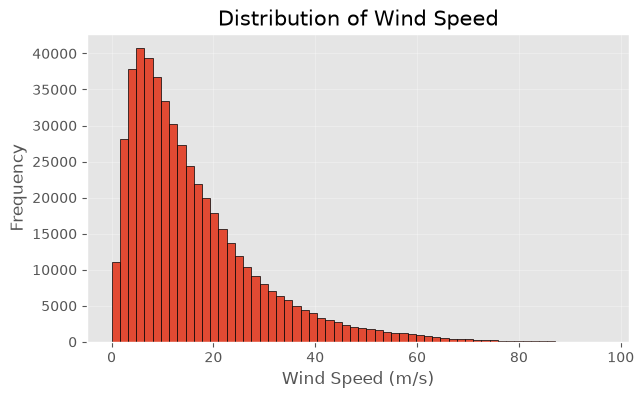

In [12]:
plt.figure(figsize=(7,4))

plt.hist(
    eda_df["wind_speed"],
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Wind Speed", fontsize=15)
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Observation

From the histogram of wind speed, the following observations can be made:

- The wind speed distribution is **positively (right) skewed**, indicating that lower wind speeds occur much more frequently than higher wind speeds.
- The majority of observations lie approximately between **3 m/s and 25 m/s**.
- The highest frequency of observations occurs around **5–10 m/s**, suggesting that moderate wind speeds are the most common in the dataset.
- As wind speed increases, the number of observations decreases steadily, forming a long right tail.
- A small number of observations exceed **60 m/s**, representing rare high-wind atmospheric events.
- No abnormal spikes or impossible wind speed values are observed, indicating good data quality.

These observations suggest that the dataset captures realistic atmospheric wind conditions and is suitable for machine learning.

1.2 Wind Direction Distribution

Wind direction represents the direction from which the wind originates and is measured in degrees ranging from **0° to 360°**.
Studying the distribution of wind direction helps us understand:
- Whether wind blows uniformly from all directions.
- If certain directions are more dominant.
- Whether directional patterns exist that may influence wind speed.
A histogram is used to visualize the frequency of different wind directions.

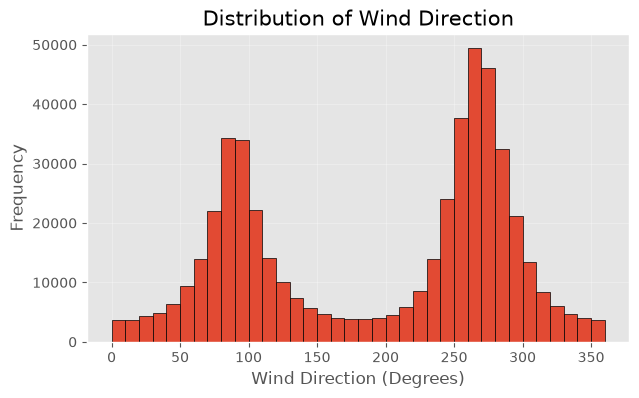

In [13]:
plt.figure(figsize=(7, 4))

plt.hist(
    eda_df["wind_direction"],
    bins=36,          # 10° intervals
    edgecolor="black"
)

plt.title("Distribution of Wind Direction", fontsize=15)
plt.xlabel("Wind Direction (Degrees)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

Observation
The histogram of wind direction reveals several important characteristics:

- The distribution is **not uniform**, indicating that wind does not blow equally from all directions.
- Two prominent peaks are observed:
  - Around **80°–100°**
  - Around **260°–280°**
- These peaks suggest that winds predominantly originate from two major directions, indicating seasonal or regional atmospheric circulation patterns.
- Wind directions between **140° and 200°** occur much less frequently, forming a noticeable trough in the distribution.
- Since wind direction exhibits clear directional preferences, it is expected to be an informative feature for predicting wind speed.

Overall, the wind direction data appears realistic and captures meaningful atmospheric circulation patterns.

1.3 Temperature Distribution

Temperature is one of the most important meteorological variables affecting atmospheric dynamics.
Analyzing its distribution helps us understand:

- The typical temperature range in the dataset.
- Whether the values are normally distributed or skewed.
- The presence of extreme temperature values.
- The overall variability of atmospheric temperature.

Since temperature is a continuous numerical variable, a histogram is used for visualization.

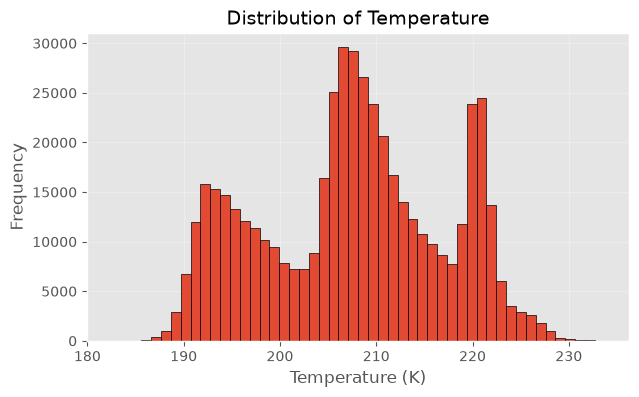

In [14]:
plt.figure(figsize=(7,4))

plt.hist(
    eda_df["temperature"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Temperature", fontsize=14)
plt.xlabel("Temperature (K)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

Observation
The temperature distribution exhibits the following characteristics:

- The temperature values range approximately from **186 K to 231 K**.
- Unlike a normal distribution, the histogram shows **multiple distinct peaks (multimodal distribution)**.
- The highest concentration of observations occurs around **206–210 K**.
- Additional peaks are visible near **193–197 K** and **219–221 K**.
- These multiple peaks indicate that the dataset contains observations from **different atmospheric pressure levels**, where temperature naturally varies with altitude.
- No unrealistic temperature values or abnormal outliers are observed.

The multimodal nature of the distribution confirms that the dataset represents measurements collected across multiple atmospheric layers, making temperature an informative feature for wind speed prediction.

1.4 Relative Humidity Distribution

Relative humidity represents the amount of water vapor present in the atmosphere relative to the maximum amount the air can hold at the same temperature.

Studying its distribution helps us understand:

- The moisture conditions across different atmospheric layers.
- Whether dry or humid conditions dominate the dataset.
- The variability of humidity values.
- Its potential influence on wind speed.

A histogram is used to visualize the distribution of relative humidity values.

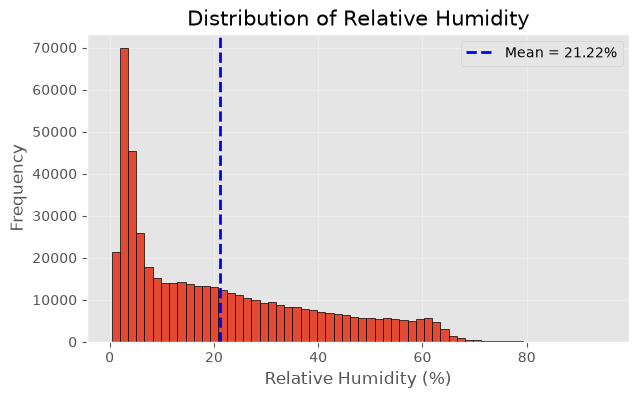

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(
    eda_df["relative_humidity"],
    bins=60,
    edgecolor="black"
)

plt.axvline(
    eda_df["relative_humidity"].mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {eda_df['relative_humidity'].mean():.2f}%"
)

plt.title("Distribution of Relative Humidity", fontsize=15)
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.legend()

plt.show()

Observation

The distribution of relative humidity exhibits the following characteristics:

- The distribution is **positively (right) skewed**, with a large concentration of observations at lower humidity levels.
- The highest frequency occurs between **2% and 8%**, indicating that low humidity conditions are the most common in the sampled dataset.
- The mean relative humidity is approximately **21.22%**, which is higher than the most frequent values due to the presence of a long right tail.
- As humidity increases, the frequency of observations gradually decreases.
- Very high humidity values (above **70%**) are relatively rare.
- No unrealistic values (below 0% or above 100%) are present, indicating good data quality.

Overall, the dataset contains predominantly dry atmospheric conditions with occasional high-humidity events.

1.5 Pressure Level Distribution

Atmospheric pressure levels represent different heights in the atmosphere.
Lower pressure values correspond to higher altitudes, while higher pressure values correspond to lower altitudes closer to the Earth's surface.

Analyzing the distribution of pressure levels helps us understand:

- Whether observations are evenly distributed across atmospheric layers.
- If all pressure levels are adequately represented.
- Whether any pressure level dominates the dataset.

Since pressure levels are discrete values, a bar chart is more appropriate than a histogram.

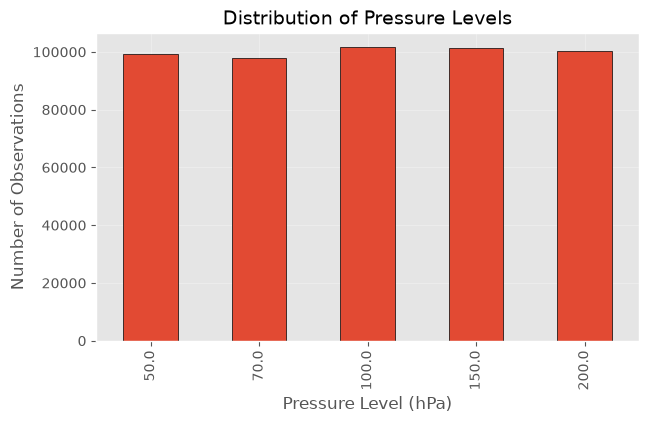

In [16]:
pressure_counts = (
    eda_df["pressure_hpa"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,4))

pressure_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Pressure Levels", fontsize=14)
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Number of Observations")

plt.grid(alpha=0.3)

plt.show()

Observation

The distribution of pressure levels shows that all five atmospheric pressure levels are well represented in the sampled dataset.

Key observations include:
- The dataset contains observations from all selected pressure levels:
  - 50 hPa
  - 70 hPa
  - 100 hPa
  - 150 hPa
  - 200 hPa
- The number of observations at each pressure level is nearly identical (approximately 100,000 observations each).
- No pressure level is significantly overrepresented or underrepresented.
- This balanced distribution ensures that the machine learning model receives sufficient training data from every atmospheric layer.
- Since each pressure level corresponds to a different altitude, the model will be able to learn altitude-dependent wind patterns effectively.

Overall, the sampled dataset provides a balanced representation of the upper atmosphere across all selected pressure levels.

1.6 Geopotential Height Distribution

Geopotential height represents the altitude of a pressure surface in the atmosphere.
It is one of the most important variables in atmospheric science because it describes the vertical structure of the atmosphere and is closely related to pressure and temperature.

Studying its distribution helps us understand:

- The range of atmospheric heights in the dataset.
- Whether multiple atmospheric layers are represented.
- The presence of unusual or extreme observations.

Since geopotential height is a continuous numerical variable, a histogram is used for visualization.

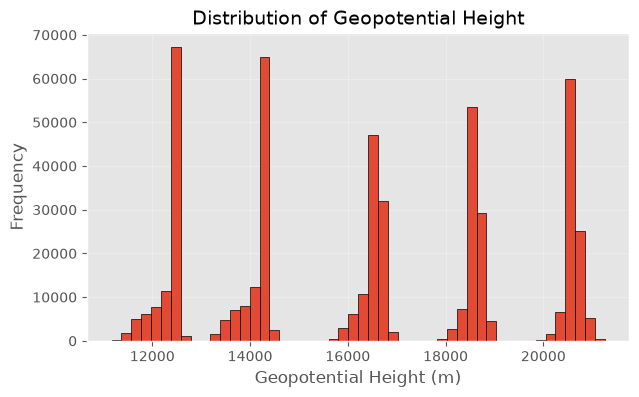

In [17]:
plt.figure(figsize=(7,4))

plt.hist(
    eda_df["geopotential_height"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Geopotential Height", fontsize=14)
plt.xlabel("Geopotential Height (m)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

Observation

The distribution of geopotential height exhibits multiple distinct peaks rather than a single continuous distribution.

Key observations include:

- The dataset contains several prominent peaks, each corresponding to one of the selected pressure levels.
- Lower pressure levels are associated with higher geopotential heights, while higher pressure levels correspond to lower altitudes.
- The multimodal distribution is expected because observations are collected from multiple atmospheric layers.
- No unrealistic or extreme values are observed.
- The geopotential height data appears physically consistent and suitable for machine learning.

1.7 Seasonal Distribution

Season is a categorical feature derived from the observation date.
Studying the seasonal distribution ensures that observations are available from all seasons, allowing the machine learning model to learn seasonal variations in atmospheric conditions.

A bar chart is used because season is a categorical variable.

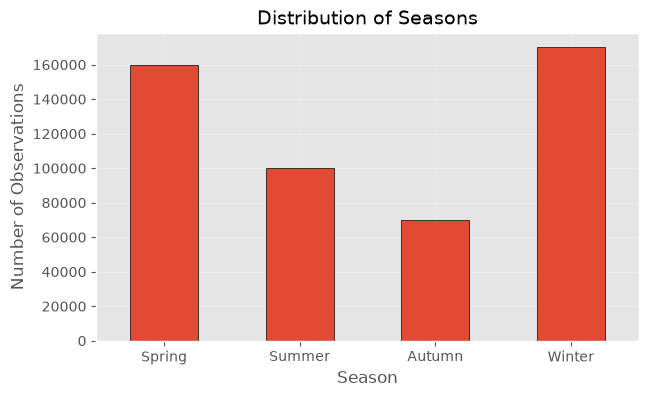

In [18]:
plt.figure(figsize=(7,4))

season_counts = (
    eda_df["season"]
    .value_counts()
    .reindex(["Spring", "Summer", "Autumn", "Winter"])
)

season_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Seasons", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Number of Observations")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

Observation

The seasonal distribution indicates that observations are available across all four seasons.
Key observations include:

- Winter contains the highest number of observations.
- Spring is the second most represented season.
- Summer contains fewer observations than Winter and Spring.
- Autumn has the smallest number of observations.
- Although the sampled dataset is not perfectly balanced across seasons, every season is sufficiently represented to capture seasonal atmospheric variations.

1.8 Monthly Distribution

The month feature represents the month in which each observation was recorded.

Analyzing the monthly distribution verifies that observations are available throughout the year, ensuring that seasonal weather patterns are adequately captured.

A bar chart is used because month is a discrete categorical feature.

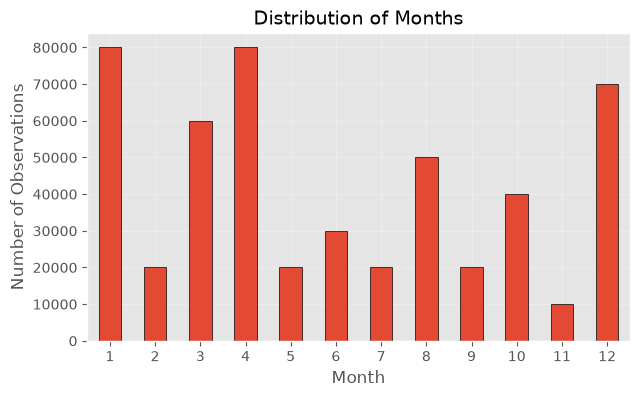

In [19]:
plt.figure(figsize=(7,4))

month_counts = (
    eda_df["month"]
    .value_counts()
    .sort_index()
)

month_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Months", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

Observation

The monthly distribution confirms that observations are available for every month of the year.

Key observations include:

- Every month is represented in the sampled dataset.
- The number of observations varies across months because the dataset was created through random sampling of files.
- January, April, and December contain the highest number of observations.
- November contains the fewest observations.
- Despite these variations, the dataset captures atmospheric conditions throughout the entire year.

1.9 Observation Hour Distribution

Weather observations in this dataset are recorded every three hours.

Analyzing the observation hours ensures that all daily time intervals are represented in the dataset.

This helps the machine learning model capture diurnal (daily) variations in atmospheric conditions.

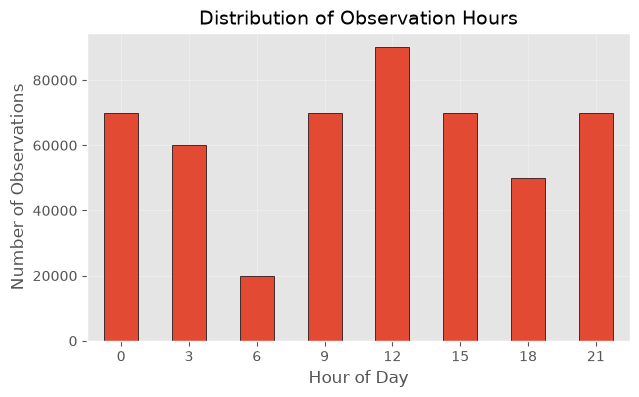

In [20]:
plt.figure(figsize=(7,4))

hour_counts = (
    eda_df["hour"]
    .value_counts()
    .sort_index()
)

hour_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Observation Hours", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

Observation

The distribution of observation hours shows that measurements are available at all scheduled observation times.

Key observations include:

- Observations exist at every 3-hour interval (00, 03, 06, 09, 12, 15, 18, and 21 UTC).
- The number of observations varies between different hours due to random sampling.
- The highest number of observations occurs at 12 UTC.
- The lowest number of observations occurs at 06 UTC.
- All observation hours are represented, allowing the model to learn daily atmospheric variations.

2. Bivariate Analysis

Bivariate analysis examines the relationship between two variables. In this project, the primary objective is to understand how different atmospheric variables influence **wind speed**, which is the target variable for the machine learning model.

The following analyses are performed:

- **Temperature vs Wind Speed** – to examine whether temperature influences wind speed.
- **Relative Humidity vs Wind Speed** – to study the relationship between atmospheric moisture and wind speed.
- **Geopotential Height vs Wind Speed** – to analyze how atmospheric height varies with wind speed.
- **Pressure Level vs Wind Speed** – to compare wind speeds across different atmospheric pressure levels.
- **Wind Direction vs Wind Speed** – to investigate whether wind speed varies with wind direction.
- **Season vs Wind Speed** – to identify seasonal variations in wind speed.
- **Month vs Wind Speed** – to study monthly trends in wind speed.
- **Correlation Analysis** – to quantify the linear relationships between numerical variables using a correlation matrix.

The insights obtained from this analysis will assist in selecting the most relevant features for training the wind speed prediction model and provide a better understanding of the factors affecting atmospheric wind behavior.

2.1 Temperature vs Wind Speed

In this section, we investigate how atmospheric temperature influences wind speed.

The objectives are to:

- Identify any visible relationship between temperature and wind speed.
- Determine whether higher temperatures are associated with stronger or weaker winds.
- Estimate the strength of the linear relationship using the Pearson correlation coefficient.

Since the dataset contains 500,000 observations, plotting every point would make the figure unreadable. Therefore, a random sample of 10,000 observations is used for visualization.

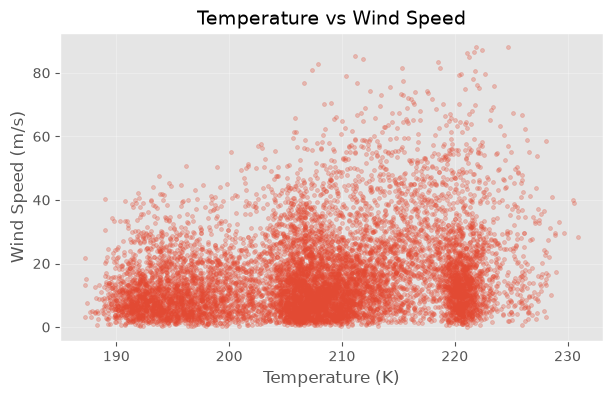

Correlation = 0.2820


In [22]:
# Sample 10,000 observations for visualization
scatter_sample = eda_df.sample(10000, random_state=42)

plt.figure(figsize=(7,4))

plt.scatter(
    scatter_sample["temperature"],
    scatter_sample["wind_speed"],
    alpha=0.3,
    s=8
)

plt.title("Temperature vs Wind Speed", fontsize=14)
plt.xlabel("Temperature (K)")
plt.ylabel("Wind Speed (m/s)")

plt.grid(alpha=0.3)

plt.show()

# Calculate correlation
corr = eda_df["temperature"].corr(eda_df["wind_speed"])

print(f"Correlation = {corr:.4f}")

Observation

The scatter plot indicates a weak positive relationship between atmospheric temperature and wind speed.
Key observations include:

- Wind speeds are observed across the entire temperature range.
- Higher temperatures tend to be associated with slightly higher wind speeds.
- The points are widely scattered, indicating that temperature alone is not a strong predictor of wind speed.
- Multiple clusters are visible because the observations come from different pressure levels.
- The Pearson correlation coefficient (~0.28) confirms a weak positive linear relationship.

Overall, temperature contributes to wind speed prediction but is not the dominant influencing factor.

2.2 Relative Humidity vs Wind Speed

This analysis examines whether atmospheric moisture influences wind speed.

A scatter plot and Pearson correlation coefficient are used to study the relationship.

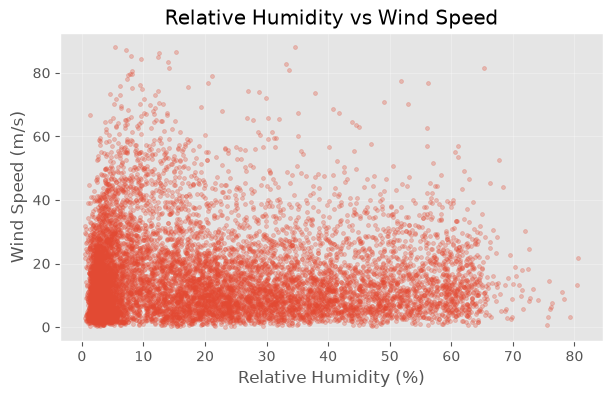

Correlation: -0.08061261832240828


In [23]:
scatter_sample = eda_df.sample(10000, random_state=42)

plt.figure(figsize=(7,4))

plt.scatter(
    scatter_sample["relative_humidity"],
    scatter_sample["wind_speed"],
    alpha=0.3,
    s=8
)

plt.title("Relative Humidity vs Wind Speed")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Wind Speed (m/s)")

plt.grid(alpha=0.3)

plt.show()

print("Correlation:", eda_df["relative_humidity"].corr(eda_df["wind_speed"]))

Observation

The relationship between relative humidity and wind speed appears weakly negative.
Key observations include:

- Most observations are concentrated below 20% relative humidity.
- Higher wind speeds are more common at lower humidity values.
- As relative humidity increases, the occurrence of very high wind speeds decreases.
- The scatter plot does not show a strong linear pattern.
- The Pearson correlation coefficient (~−0.08) indicates a very weak negative relationship.

Relative humidity alone has limited predictive power for wind speed.

2.3 Geopotential Height vs Wind Speed

Geopotential height represents atmospheric altitude.

This analysis investigates whether wind speed changes with atmospheric height.

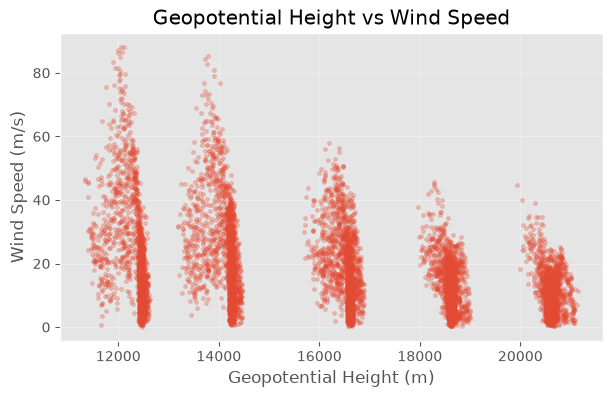

Correlation: -0.40273017908167014


In [24]:
scatter_sample = eda_df.sample(10000, random_state=42)

plt.figure(figsize=(7,4))

plt.scatter(
    scatter_sample["geopotential_height"],
    scatter_sample["wind_speed"],
    alpha=0.3,
    s=8
)

plt.title("Geopotential Height vs Wind Speed")
plt.xlabel("Geopotential Height (m)")
plt.ylabel("Wind Speed (m/s)")

plt.grid(alpha=0.3)

plt.show()

print("Correlation:", eda_df["geopotential_height"].corr(eda_df["wind_speed"]))

Observation

The scatter plot shows that wind speed varies systematically with geopotential height.
Key observations include:

- Distinct vertical clusters correspond to the different pressure levels.
- Higher wind speeds are generally observed at lower geopotential heights.
- Wind speed tends to decrease as geopotential height increases.
- The relationship is moderately negative.
- The Pearson correlation coefficient (~−0.40) confirms a moderate inverse relationship.

Geopotential height is an informative predictor for wind speed.

2.4 Pressure Level vs Wind Speed

Pressure level represents different atmospheric layers.

A box plot is used to compare the distribution of wind speed across the selected pressure levels.

<Figure size 700x400 with 0 Axes>

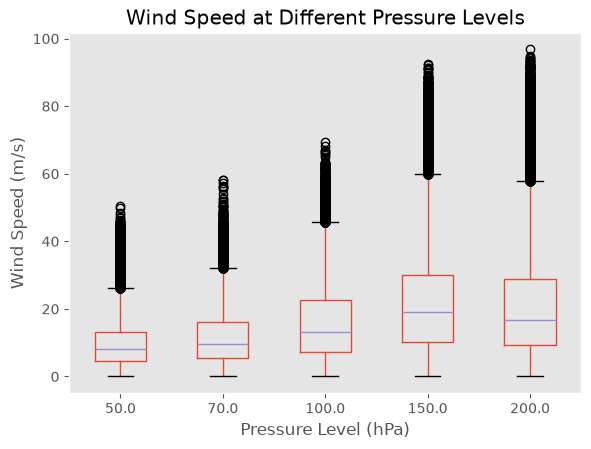

In [26]:
plt.figure(figsize=(7,4))

eda_df.boxplot(
    column="wind_speed",
    by="pressure_hpa",
    grid=False
)

plt.title("Wind Speed at Different Pressure Levels")
plt.suptitle("")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Wind Speed (m/s)")

plt.show()

Observation

The box plot illustrates the variation of wind speed across atmospheric pressure levels.
Key observations include:

- Wind speed distributions differ considerably across pressure levels.
- The 150 hPa and 200 hPa levels exhibit the highest median wind speeds.
- Lower pressure levels (50 hPa and 70 hPa) generally have lower wind speeds.
- Higher pressure levels also show greater variability and more extreme wind speed values.
- The presence of numerous outliers indicates occasional high-wind events.

Pressure level has a significant influence on wind speed and is an important feature for prediction.

2.5 Wind Direction vs Wind Speed

Wind direction indicates the direction from which the wind originates.

This analysis examines whether wind speed varies across different wind directions.

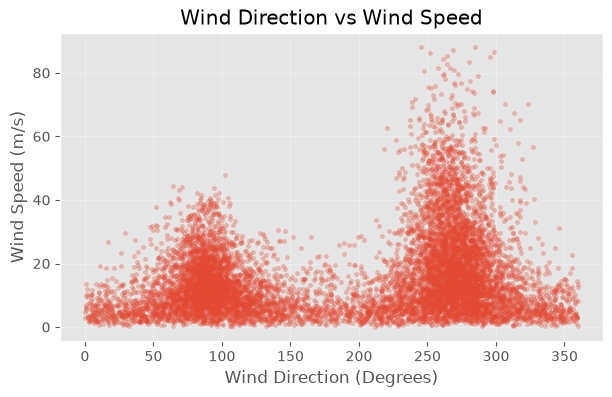

Correlation: 0.2504085443834334


In [27]:
scatter_sample = eda_df.sample(10000, random_state=42)

plt.figure(figsize=(7,4))

plt.scatter(
    scatter_sample["wind_direction"],
    scatter_sample["wind_speed"],
    alpha=0.3,
    s=8
)

plt.title("Wind Direction vs Wind Speed")
plt.xlabel("Wind Direction (Degrees)")
plt.ylabel("Wind Speed (m/s)")

plt.grid(alpha=0.3)

plt.show()

print("Correlation:", eda_df["wind_direction"].corr(eda_df["wind_speed"]))

Observation

The relationship between wind direction and wind speed is nonlinear.
Key observations include:

- Wind speeds are concentrated around two dominant directional ranges, approximately 90° and 270°.
- The strongest winds occur predominantly around 260°–280°.
- Wind speed does not increase or decrease consistently with direction.
- The Pearson correlation coefficient (~0.25) is relatively low because correlation measures only linear relationships.

Although wind direction shows directional patterns, it should be treated as a circular feature rather than a standard numerical variable.

2.6 Seasonal Variation of Wind Speed

Different seasons exhibit different atmospheric circulation patterns.

A box plot is used to compare wind speed distributions across seasons.

<Figure size 700x400 with 0 Axes>

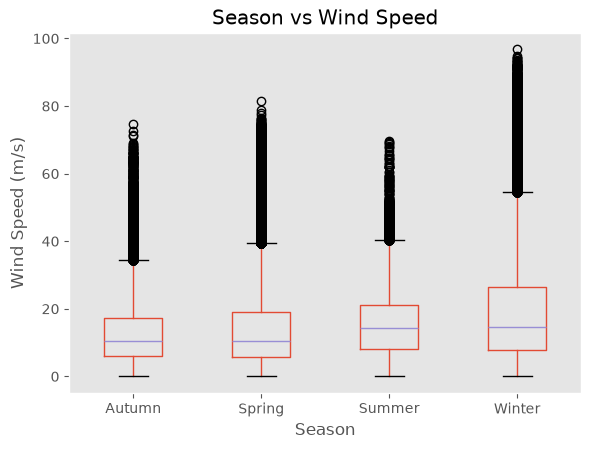

In [28]:
plt.figure(figsize=(7,4))

eda_df.boxplot(
    column="wind_speed",
    by="season",
    grid=False
)

plt.title("Season vs Wind Speed")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Wind Speed (m/s)")

plt.show()

Observation

The box plot reveals noticeable seasonal variation in wind speed.
Key observations include:

- Winter exhibits the highest median wind speed.
- Summer also experiences relatively high wind speeds.
- Autumn records the lowest median wind speed.
- Winter shows the largest spread and the greatest number of extreme wind events.
- Seasonal differences indicate that atmospheric circulation changes throughout the year significantly influence wind speed.

Season is therefore a useful categorical feature for wind speed prediction.

2.7 Monthly Variation of Wind Speed

Monthly analysis helps identify long-term seasonal trends in wind speed throughout the year.

<Figure size 700x400 with 0 Axes>

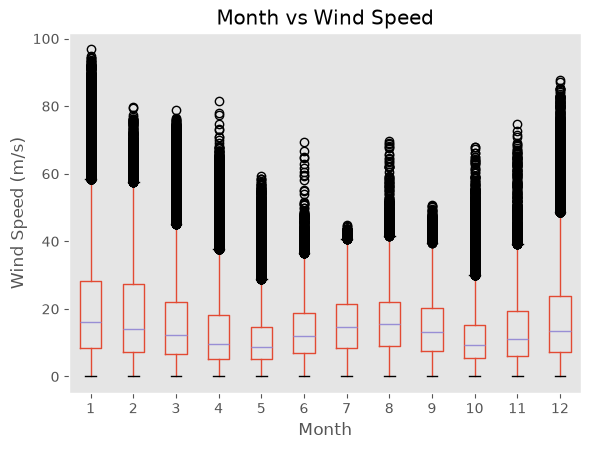

In [29]:
plt.figure(figsize=(7,4))

eda_df.boxplot(
    column="wind_speed",
    by="month",
    grid=False
)

plt.title("Month vs Wind Speed")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Wind Speed (m/s)")

plt.show()

Observation

Wind speed varies across different months of the year.
Key observations include:

- January and December exhibit the highest wind speeds.
- May records comparatively lower wind speeds.
- Monthly distributions differ in both median values and variability.
- Several months contain numerous extreme wind events.
- These variations reflect seasonal atmospheric patterns and justify including the month feature in the prediction model.

2.8 Correlation Heatmap

A correlation heatmap summarizes the linear relationships among numerical features.

Correlation values range from -1 to +1:

- +1 indicates a perfect positive relationship.
- -1 indicates a perfect negative relationship.
- 0 indicates no linear relationship.

This visualization helps identify the variables most strongly associated with wind speed.

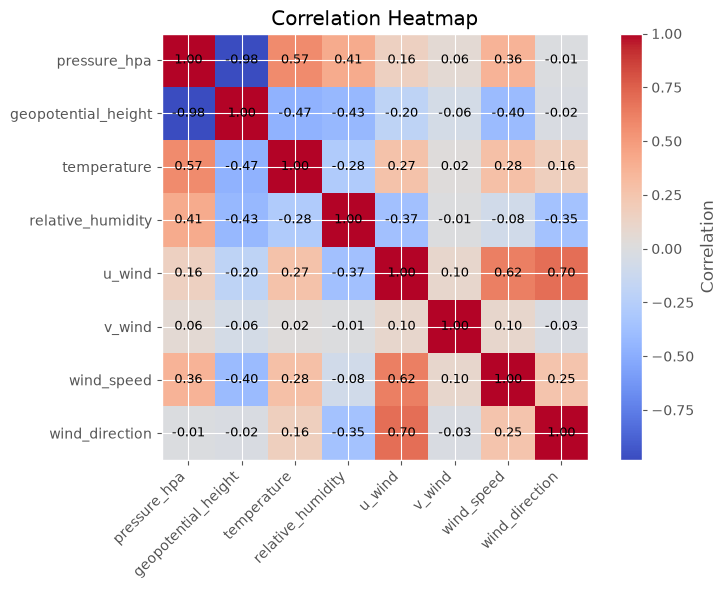

In [31]:
numeric_cols = [
    "pressure_hpa",
    "geopotential_height",
    "temperature",
    "relative_humidity",
    "u_wind",
    "v_wind",
    "wind_speed",
    "wind_direction"
]

corr = eda_df[numeric_cols].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

# Write correlation values inside each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Observation

The correlation heatmap summarizes the relationships among all numerical variables.
Key observations include:

- Wind speed has the strongest positive correlation with the U-component of wind (0.62).
- Geopotential height is moderately negatively correlated with wind speed (−0.40).
- Pressure level shows a moderate positive correlation with wind speed (0.36).
- Temperature has a weak positive correlation with wind speed (0.28).
- Relative humidity exhibits only a very weak negative correlation (−0.08).
- Pressure level and geopotential height are strongly negatively correlated (−0.98), which is expected because higher pressure levels correspond to lower atmospheric altitudes.
- Wind direction has only a weak linear correlation with wind speed (0.25), suggesting a nonlinear relationship.

Overall, pressure level, geopotential height, temperature, and the wind components are the most informative predictors for wind speed.